INFO: Auto-setting vmin to -1.165e-01 [aplpy.core]
INFO: Auto-setting vmax to  2.396e-01 [aplpy.core]
INFO: Auto-setting vmin to -8.466e-02 [aplpy.core]
INFO: Auto-setting vmax to  2.140e-01 [aplpy.core]
INFO: Auto-setting resolution to 199.101 dpi [aplpy.core]


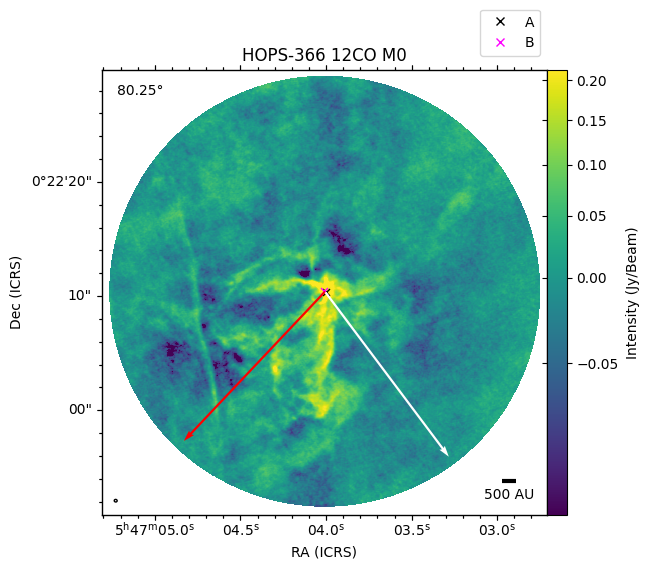

In [9]:
import astropy.io.fits as fits
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import os
import pandas as pd

from create_figs import create_m0_map

import warnings
warnings.filterwarnings("ignore")

def angle_between_vectors(v1, v2):
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    a = np.arccos(np.clip(cos_theta, -1.0, 1.0)) * (180 / np.pi)
    return a

# data
df = pd.read_csv('../data/outflow_data.csv')


# This loops through each source field with an angle measurement and creates
# a figure with the separation vector an outflow vector overlayed
overwrite = False
for i, field in df.iterrows():

    # verify output path exists and
    # skip already existing files if you don't want to overwrite them
    target_name = field['field']

    if target_name != 'HOPS-366':
        continue

    output_path = f"../results/{target_name}_outflow_m0.pdf"
    if (os.path.exists(output_path)) and (not overwrite):
        continue

    # open image
    hdulist = fits.open(f"/Volumes/Alpha/Research/data/{target_name.casefold()}/{target_name.casefold()}__s15__12co.fits")
    hdu = hdulist[0]

    # crop field
    center_ra = hdu.header['OBSRA']
    center_dec = hdu.header['OBSDEC']
    center = SkyCoord(center_ra, center_dec, unit=u.degree)
    size = np.array([39, 39]) * u.arcsecond

    # create figure
    channel_idx = np.r_[80:87, 112:120]
    fig = create_m0_map(hdu, center, size, channel_idx, distance=field['distance'])
    fig.set_title(f"{target_name} 12CO M0")
    fig.show_colorscale(cmap='viridis', stretch='sqrt')

    # add a marker at each source with legend
    center_a = SkyCoord(field['source_a_ra'], field['source_a_dec'], unit=u.degree)
    center_b = SkyCoord(field['source_b_ra'], field['source_b_dec'], unit=u.degree)
    fig.show_markers(center_a.ra.deg, center_a.dec.deg, coords_frame='world', marker='x', s=25, c='black', linewidths=1, label=field['source_a'])
    fig.show_markers(center_b.ra.deg, center_b.dec.deg, coords_frame='world', marker='x', s=25, c='magenta', linewidths=1, label=field['source_b'])
    legend_handles = []
    legend_handles.append(mlines.Line2D([], [], color='black', marker='x', markersize=6, linestyle='None', label=field['source_a']))
    legend_handles.append(mlines.Line2D([], [], color='magenta', marker='x', markersize=6, linestyle='None', label=field['source_b']))
    fig.ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1,1.15))


    ### calculate outflow vector
    angle_north = field['angle']
    angle_east_rad = np.radians(90 - angle_north)
    # get coordinate vectors
    # define outflow origin between the sources
    outflow_origin = np.array([np.mean([field['source_a_ra'], field['source_b_ra']]), np.mean([field['source_a_dec'], field['source_b_dec']])])
    outflow_tip_pix = fig.world2pixel(outflow_origin[0] + 0.005 * np.cos(angle_east_rad), outflow_origin[1] + 0.005 * np.sin(angle_east_rad))
    outflow_origin_pix = fig.world2pixel(outflow_origin[0], outflow_origin[1])
    # get outflow vector
    outflow_vector = np.array([outflow_tip_pix[0] - outflow_origin_pix[0], outflow_tip_pix[1] - outflow_origin_pix[1]])
    # plot outflow vector
    fig.ax.quiver(outflow_origin_pix[0], outflow_origin_pix[1], outflow_vector[0], outflow_vector[1],
                angles='xy', scale_units='xy', scale=1, color='red', width=0.005)


    ### calculate separation vector
    # get coordinate vectors
    star_a_pix = fig.world2pixel(center_a.ra.deg, center_a.dec.deg)
    star_b_pix = fig.world2pixel(center_b.ra.deg, center_b.dec.deg)
    # get separation vector
    separation_vector = np.array([star_a_pix[0] - star_b_pix[0], star_a_pix[1] - star_b_pix[1]])
    # normalize to same length as outflow vector
    separation_vector = np.linalg.norm(outflow_vector) * separation_vector / np.linalg.norm(separation_vector)
    # get smallest angle
    angle = angle_between_vectors(outflow_vector, separation_vector)
    if angle > 90:
        # recompute for the smaller angle
        separation_vector = np.array([star_b_pix[0] - star_a_pix[0], star_b_pix[1] - star_a_pix[1]])
        separation_vector = np.linalg.norm(outflow_vector) * separation_vector / np.linalg.norm(separation_vector)
        angle = angle_between_vectors(outflow_vector, separation_vector)
    # plot separation vector
    fig.ax.quiver(star_a_pix[0], star_a_pix[1], separation_vector[0], separation_vector[1],
                angles='xy', scale_units='xy', scale=1, color='white', width=0.005)


    # display angle between outflow and separation in top left corner
    fig.ax.text(30,fig.ax.get_xlim()[1]-50, f"{angle:.2f}°")

    # save image
    fig.savefig(output_path)